# Pandas : Explode

**Method**
- df.explode()

In [4]:
# Import Libraries
from datasets import load_dataset
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load dataset
raw = load_dataset('lukebarousse/data_jobs')
data=raw['train'].to_pandas().copy()
df = data.copy()

# Converting job_posted_date column into datetime and job_skills into list type 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


**Example for explode() Method**

In [5]:
dict_skill={
    'job_title':['Data Analyst','Data Scientist', 'Data Engineer'],
    'Job_skills':[['SQL','Python','Excel','Power BI'],['Python','R'],["Python",'SQL','PySpark','Airflow']]
}
df_dict = pd.DataFrame(dict_skill)
type(df_dict)

pandas.DataFrame

In [6]:
df_dict

,job_title,Job_skills
0,Data Analyst,"[SQL, Python, Excel, Power BI]"
1,Data Scientist,"[Python, R]"
2,Data Engineer,"[Python, SQL, PySpark, Airflow]"


In [13]:
df_dict_explode= df_dict.explode(column='Job_skills')
df_dict_explode

,job_title,Job_skills
0,Data Analyst,SQL
0,Data Analyst,Python
0,Data Analyst,Excel
0,Data Analyst,Power BI
1,Data Scientist,Python
1,Data Scientist,R
2,Data Engineer,Python
2,Data Engineer,SQL
2,Data Engineer,PySpark
2,Data Engineer,Airflow


In [16]:
df_dict_explode.value_counts()

job_title       Job_skills
Data Analyst    SQL           1
                Python        1
                Excel         1
                Power BI      1
Data Scientist  Python        1
                R             1
Data Engineer   Python        1
                SQL           1
                PySpark       1
                Airflow       1
Name: count, dtype: int64

In [15]:
df_dict_explode.value_counts('Job_skills')

Job_skills
Python      3
SQL         2
Excel       1
Power BI    1
R           1
PySpark     1
Airflow     1
Name: count, dtype: int64

<Axes: xlabel='Job_skills'>

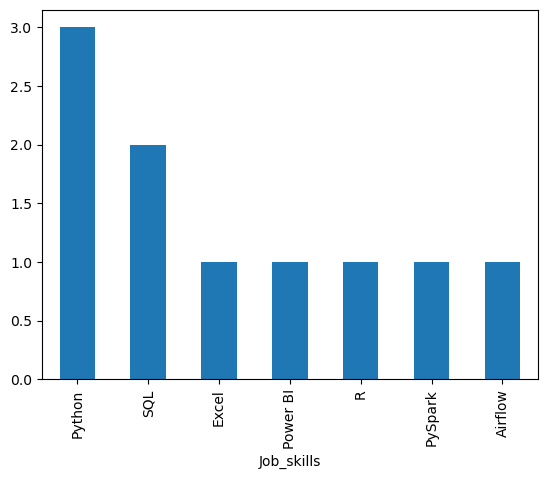

In [17]:
df_dict_explode.value_counts('Job_skills').plot(kind='bar')

**2. Example**

In [19]:
df_explode=df.explode(column='job_skills')

In [23]:
df_explode.value_counts('job_skills').head(10)


job_skills
sql         384849
python      380909
aws         145381
azure       132527
r           130892
tableau     127213
excel       127018
spark       114609
power bi     98147
java         85612
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

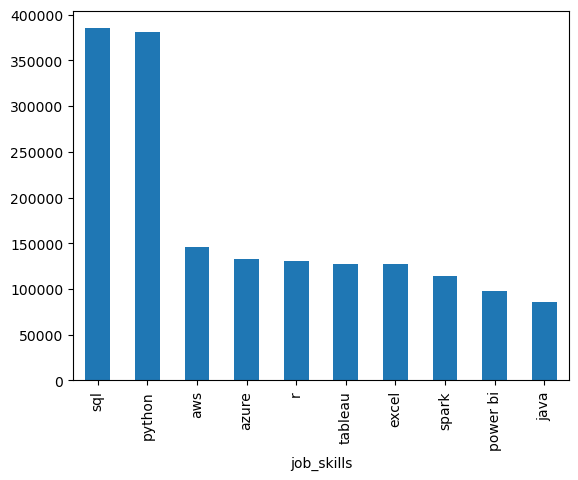

In [25]:
df_explode.value_counts('job_skills').head(10).plot(kind='bar')

**with Groupby() Method**

In [43]:
df_group =df_explode.groupby(['job_title_short','job_skills']).size()

In [44]:
df_group = df_group.reset_index(name='skill_count')


In [52]:
df_group = df_group.sort_values('skill_count',ascending=False)
df_group

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
776,Data Engineer,linode,1
1843,Senior Data Scientist,delphi,1
1888,Senior Data Scientist,kali,1
1289,Machine Learning Engineer,powerbi,1


In [53]:
job_title = 'Data Analyst'
top_skills = 10

df_skills = (df_group[df_group['job_title_short']==job_title]).head(top_skills)
df_skills

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


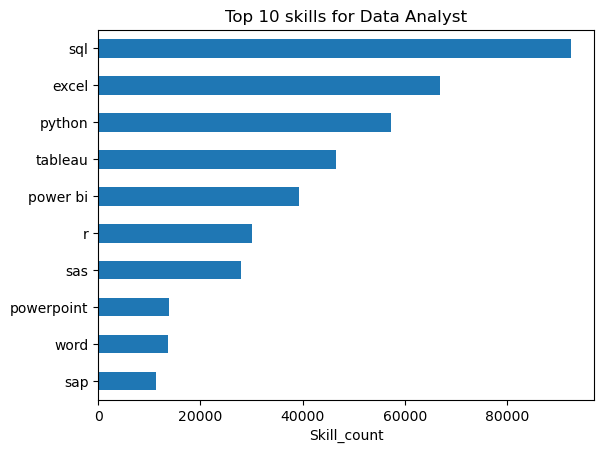

In [66]:
df_skills.plot(
    kind='barh',
    x='job_skills',
    y='skill_count'
)
plt.legend().set_visible(False)
plt.title(f'Top {top_skills} skills for {job_title}')
plt.xlabel('Skill_count')
plt.ylabel('')
plt.gca().invert_yaxis()
